In [1]:
import pandas as pd
from math import ceil
import matplotlib.pyplot as plt

df = pd.read_csv('../../Neuronales_Netz/Fahrradzaehlung_komplett_rolling_mean_int.csv',
                 sep=',')
df['time'] = pd.to_datetime(df['time'])
df['days'] = df['time'].dt.date

df = pd.DataFrame(df.groupby('days')['rhenusallee'].sum())
header = 'rhenusallee'

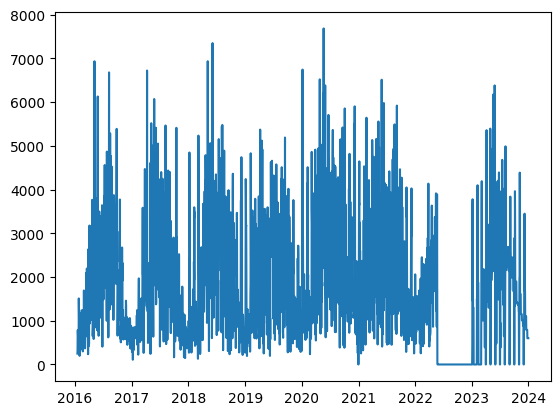

In [2]:
plt.plot(df[header])

In [3]:
df.index = pd.to_datetime(df.index)
type(df.index)

pandas.core.indexes.datetimes.DatetimeIndex

In [4]:
df.index = pd.date_range(start=df.index[0], periods=len(df), freq='D')

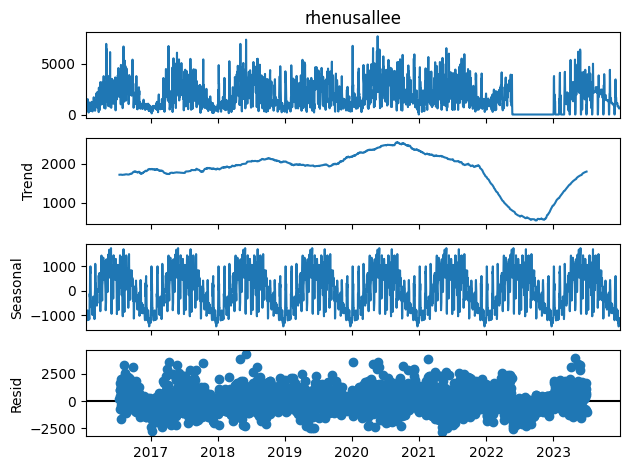

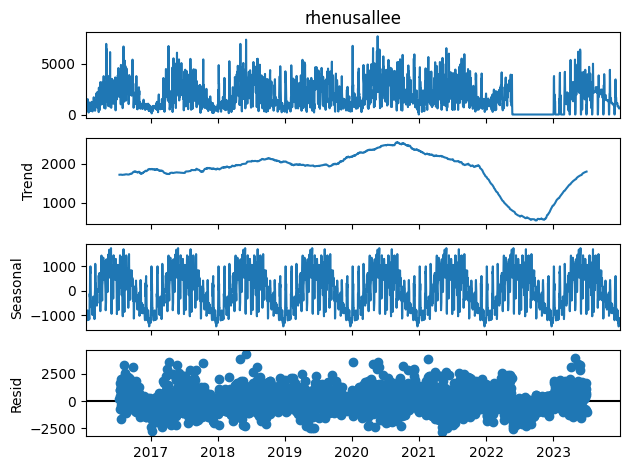

In [5]:
from statsmodels.tsa.seasonal import seasonal_decompose
decomposition = seasonal_decompose(df[header], period=365)
decomposition.plot()

In [6]:
from statsmodels.tsa.stattools import adfuller
result = adfuller(df[header])
print("Test statistic = {:.4f}".format(result[0]))
print("p-value = {:.4f}".format(result[1]))

Test statistic = -3.2692
p-value = 0.0163


In [7]:
#probiere logged first differences
from sklearn.preprocessing import MinMaxScaler
import numpy as np
maximum = max(df[header])
scaler = MinMaxScaler(feature_range=(1,maximum))
data = df[[header]]
model=scaler.fit(data)
scaled_data=model.transform(data)
df['scaled'] = scaled_data
df['log'] = np.log(df['scaled'])

In [8]:
#Aufteilung Trainings- und Testdaten

end_train = ceil(len(df) * 0.9)
df_train = df.iloc[:end_train]
df_test = df.iloc[end_train:]

In [9]:
df_train.loc[:,'differences'] = df_train.loc[:,header].diff(periods=365)
result = adfuller(df_train['differences'].dropna())
print("Test statistic = {:.4f}".format(result[0]))
print("P-value = {:.4f}".format(result[1]))

C:\Users\caddowallace\AppData\Local\Temp\ipykernel_284\3224188387.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_train.loc[:,'differences'] = df_train.loc[:,header].diff(periods=365)


Test statistic = -5.3254
P-value = 0.0000


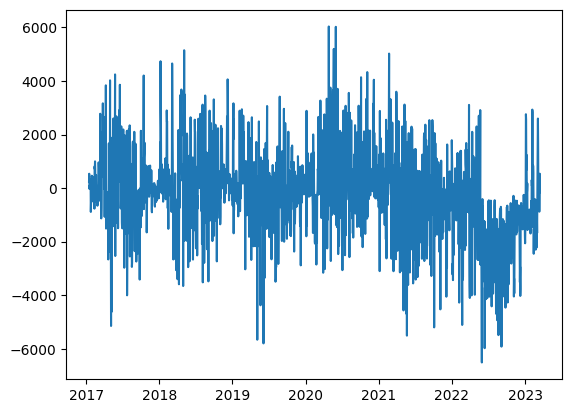

In [10]:
plt.plot(df_train.loc[:,'differences'] )

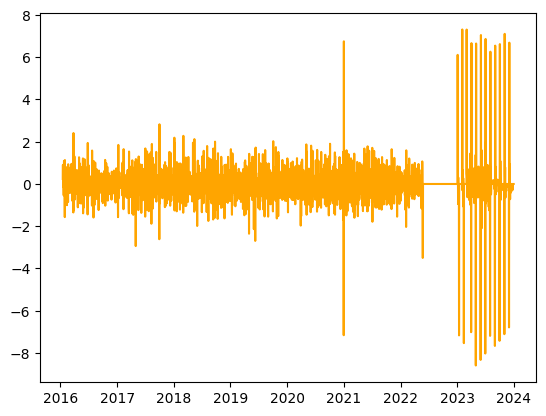

In [11]:
df['first_logged_diff'] = df['log'].diff().dropna()

plt.plot(df['first_logged_diff'], color='orange')
plt.show()

In [12]:
result = adfuller(df['first_logged_diff'].dropna())
print("Test statistic = {:.4f}".format(result[0]))
print("P-value = {:.4f}".format(result[1]))

Test statistic = -25.2341
P-value = 0.0000


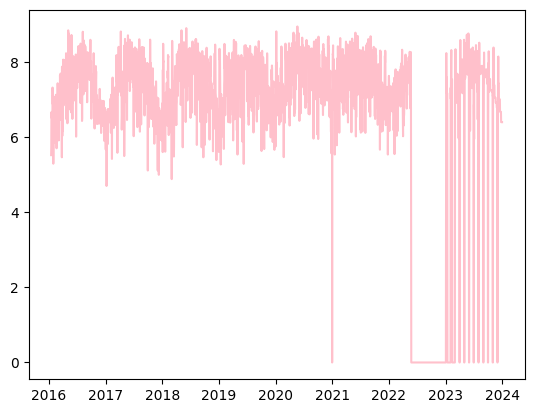

In [13]:
plt.plot(df['log'], color='pink')

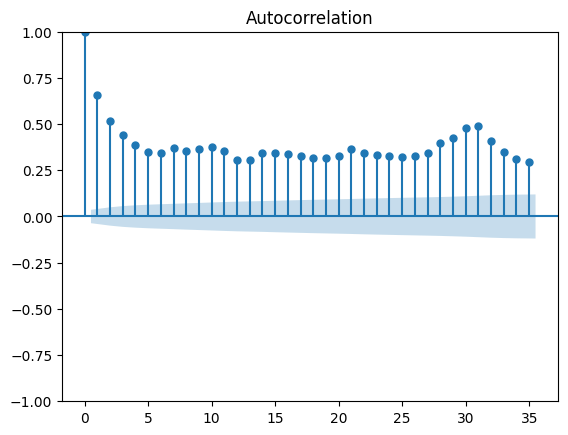

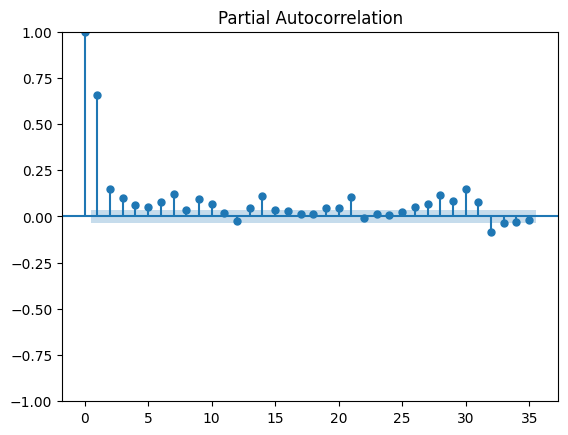

In [14]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
plot_acf(df[header])
plot_pacf(df[header])
plt.show()

In [15]:
df_train.index = pd.to_datetime(df_train.index)
df_train = df_train.asfreq('D')
df_test = df_test.asfreq('D')

from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_percentage_error
start_date= '2023-03-17'
end_date = '2023-12-31'
future_date='2024-02-28'
#Log Likelyhood: hoch, AIC: niedrig



In [16]:
def ma_arima():
    for i in range(1, 7):
        p, d, q = i, 1, 0

        arima = SARIMAX(df_train['log'], order=(p, d, q))
        result = arima.fit()
        #print(result.summary())
        print('Log Likelihood: {:.4f}, AIC: {:.4f}'.format(result.llf, result.aic))
        # Update des DataFrames
        df['differences'] = df_train['differences']
        model = SARIMAX(df['log'], order=(p, d, q))
        result_new = model.filter(result.params)

        # Vorhersage
        predicted = result_new.predict(start=start_date, end=future_date)
        tmp = pd.DataFrame(predicted)
        tmp['crossings'] = tmp['predicted_mean']
        tmp.index = tmp.index.date
        tmp['crossings'] =  np.exp(tmp['crossings'])
        tmp['crossings'] = scaler.inverse_transform(tmp[['crossings']])

        # Mergen der Daten
        df_r = pd.concat([df_train, tmp], axis=1)
        #df_r = df_train.merge(tmp, how='left', left_index=True, right_index=True)

        df_r[header] = df_r[header].fillna(df_r['crossings'])
        df_r = pd.DataFrame(df_r)
        df_r.index = pd.to_datetime(df_r.index)

        # Plotten
        plt.title('MA, Ordnung = {:.0f}'.format(i))
        plt.plot(df_r.loc[start_date:future_date, header],
             color='yellow', label='predicted')
        plt.plot(df.loc[start_date:end_date, header], color='blue', label='actual')
        plt.legend()
        plt.show()

        y_pred_simple = df_test[header].iloc[:-1]
        y_pred_simple = pd.concat([y_pred_simple, df_train[header].iloc[-1:]])
        y_pred_simple = y_pred_simple.sort_index().tolist()

        df_test.loc[:,'intervals'] = (df_test[header] > 10).astype(int).diff().fillna(0).ne(0).cumsum()
        df_test.loc[:,'group'] = df_test[header].apply(lambda x: '≤ 10' if x <= 10 else '> 10')
        df_test.loc[:,'predicted'] = df_r.loc[start_date:end_date, header]
        df_test.loc[:,'simple_predict'] = y_pred_simple

        greater = df_test[df_test['group'] == '> 10']
        mape_arima = []
        mape_simple = []

        for name, group in greater.groupby('intervals'):
            mape_arima.append(mean_absolute_percentage_error(group[header], group['predicted']))
            mape_simple.append(mean_absolute_percentage_error(group[header], group['simple_predict']))

        mae_arima = np.mean(np.abs(df_test[header] - predicted))
        mse_arima = np.mean(np.square(df_test[header] - predicted))
        mape_arima = sum(mape_arima)/len(mape_arima)
        mae_simple = np.mean(np.abs(df_test[header] - y_pred_simple))
        mse_simple = np.mean(np.square(df_test[header] - y_pred_simple))
        mape_simple = sum(mape_simple)/len(mape_simple)

        print("mean absolute error (mae): ARIMA: {:.4f}, simple: {:.4f}".format(mae_arima, mae_simple))
        print("mean squared error (mse): ARIMA: {:.4f}, simple: {:.4f}".format(mse_arima, mse_simple))
        print("mean absolute percentage error (mape): ARIMA: {:.4f}, simple: {:.4f}".format(mape_arima, mape_simple))

Log Likelihood: -2687.8089, AIC: 5379.6177


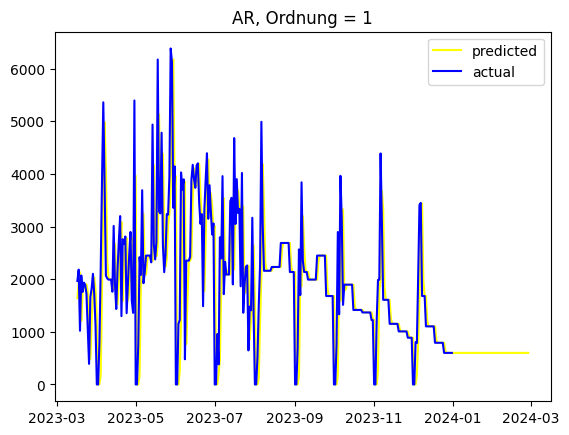

mean absolute error (mae): ARIMA: 2031.2703, simple: 622.0345
mean squared error (mse): ARIMA: 5538149.9819, simple: 1171352.5655
mean absolute percentage error (mape): ARIMA: 0.3065, simple: 0.3035
Log Likelihood: -2675.3806, AIC: 5356.7612


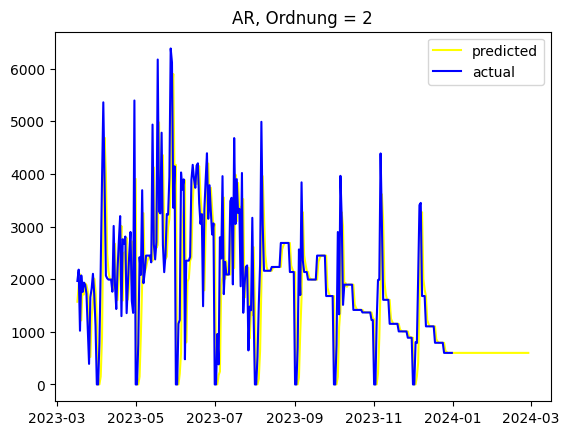

mean absolute error (mae): ARIMA: 2031.2803, simple: 622.0345
mean squared error (mse): ARIMA: 5538258.4102, simple: 1171352.5655
mean absolute percentage error (mape): ARIMA: 0.3143, simple: 0.3035
Log Likelihood: -2666.3868, AIC: 5340.7735


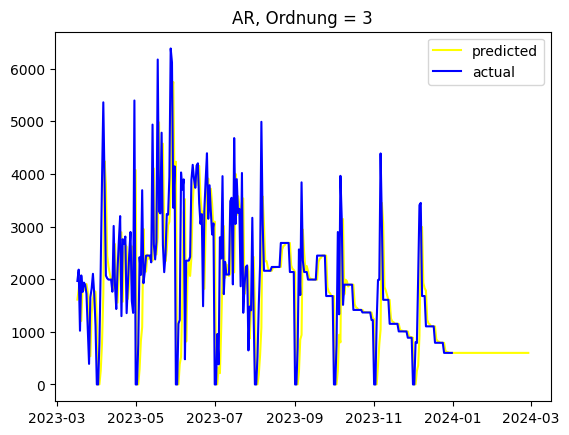

mean absolute error (mae): ARIMA: 2031.2844, simple: 622.0345
mean squared error (mse): ARIMA: 5538361.3588, simple: 1171352.5655
mean absolute percentage error (mape): ARIMA: 0.3108, simple: 0.3035
Log Likelihood: -2662.3179, AIC: 5334.6357


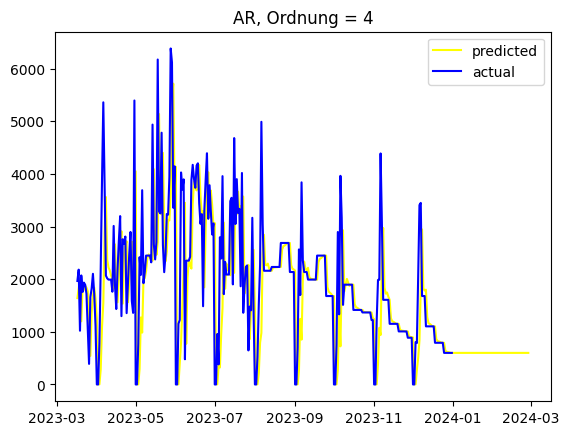

mean absolute error (mae): ARIMA: 2031.2861, simple: 622.0345
mean squared error (mse): ARIMA: 5538404.9943, simple: 1171352.5655
mean absolute percentage error (mape): ARIMA: 0.3084, simple: 0.3035
Log Likelihood: -2657.6507, AIC: 5327.3014


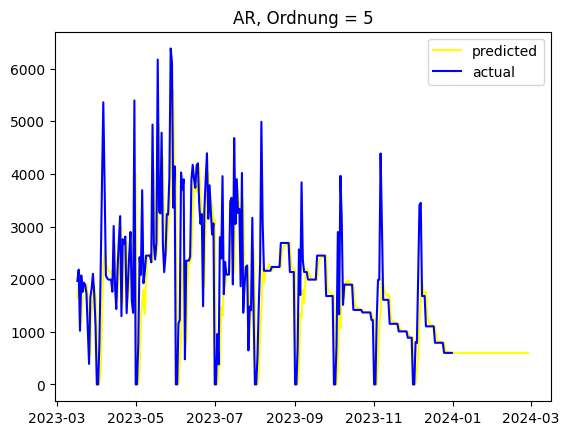

mean absolute error (mae): ARIMA: 2031.2865, simple: 622.0345
mean squared error (mse): ARIMA: 5538363.8912, simple: 1171352.5655
mean absolute percentage error (mape): ARIMA: 0.2868, simple: 0.3035
Log Likelihood: -2652.1579, AIC: 5318.3157


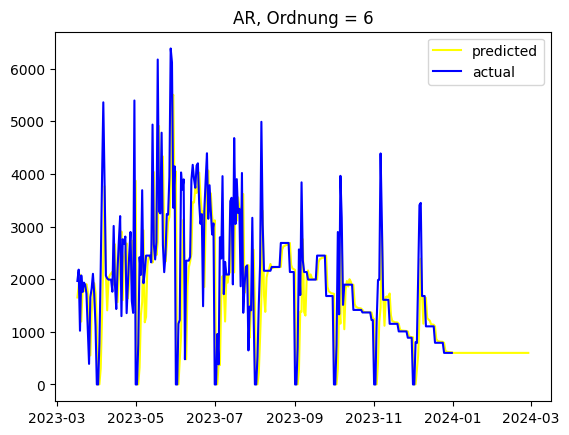

mean absolute error (mae): ARIMA: 2031.2880, simple: 622.0345
mean squared error (mse): ARIMA: 5538326.5205, simple: 1171352.5655
mean absolute percentage error (mape): ARIMA: 0.2859, simple: 0.3035
Log Likelihood: -2652.0271, AIC: 5320.0543


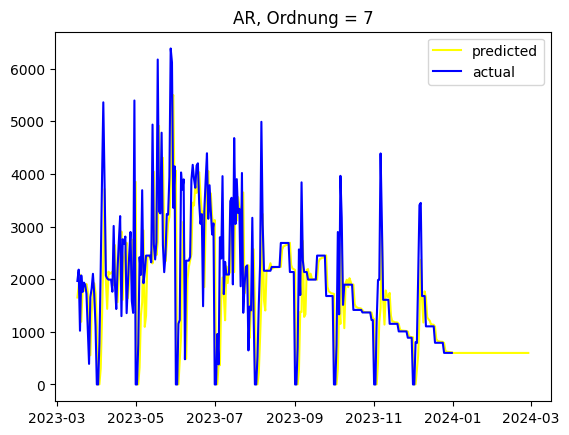

mean absolute error (mae): ARIMA: 2031.2877, simple: 622.0345
mean squared error (mse): ARIMA: 5538325.6178, simple: 1171352.5655
mean absolute percentage error (mape): ARIMA: 0.2851, simple: 0.3035


In [17]:
for i in range(1, 8):
    p, d, q = i, 1, 0

    arima = SARIMAX(df_train['log'], order=(p, d, q))
    result = arima.fit()
    #print(result.summary())
    print('Log Likelihood: {:.4f}, AIC: {:.4f}'.format(result.llf, result.aic))
    # Update des DataFrames
    df['differences'] = df_train['differences']
    model = SARIMAX(df['log'], order=(p, d, q))
    result_new = model.filter(result.params)

    # Vorhersage
    predicted = result_new.predict(start=start_date, end=future_date)
    tmp = pd.DataFrame(predicted)
    tmp['crossings'] = tmp['predicted_mean']
    tmp.index = tmp.index.date
    tmp['crossings'] =  np.exp(tmp['crossings'])
    tmp['crossings'] = scaler.inverse_transform(tmp[['crossings']])

    # Mergen der Daten
    df_r = pd.concat([df_train, tmp], axis=1)
    #df_r = df_train.merge(tmp, how='left', left_index=True, right_index=True)

    df_r[header] = df_r[header].fillna(df_r['crossings'])
    df_r = pd.DataFrame(df_r)
    df_r.index = pd.to_datetime(df_r.index)

    # Plotten
    plt.title('AR, Ordnung = {:.0f}'.format(i))
    plt.plot(df_r.loc[start_date:future_date, header],
         color='yellow', label='predicted')
    plt.plot(df.loc[start_date:end_date, header], color='blue', label='actual')
    plt.legend()
    plt.show()

    y_pred_simple = df_test[header].iloc[:-1]
    y_pred_simple = pd.concat([y_pred_simple, df_train[header].iloc[-1:]])
    y_pred_simple = y_pred_simple.sort_index().tolist()

    df_test.loc[:,'intervals'] = (df_test[header] > 10).astype(int).diff().fillna(0).ne(0).cumsum()
    df_test.loc[:,'group'] = df_test[header].apply(lambda x: '≤ 10' if x <= 10 else '> 10')
    df_test.loc[:,'predicted'] = df_r.loc[start_date:end_date, header]
    df_test.loc[:,'simple_predict'] = y_pred_simple

    greater = df_test[df_test['group'] == '> 10']
    mape_arima = []
    mape_simple = []

    for name, group in greater.groupby('intervals'):
        mape_arima.append(mean_absolute_percentage_error(group[header], group['predicted']))
        mape_simple.append(mean_absolute_percentage_error(group[header], group['simple_predict']))

    mae_arima = np.mean(np.abs(df_test[header] - predicted))
    mse_arima = np.mean(np.square(df_test[header] - predicted))
    mape_arima = sum(mape_arima)/len(mape_arima)
    mae_simple = np.mean(np.abs(df_test[header] - y_pred_simple))
    mse_simple = np.mean(np.square(df_test[header] - y_pred_simple))
    mape_simple = sum(mape_simple)/len(mape_simple)

    print("mean absolute error (mae): ARIMA: {:.4f}, simple: {:.4f}".format(mae_arima, mae_simple))
    print("mean squared error (mse): ARIMA: {:.4f}, simple: {:.4f}".format(mse_arima, mse_simple))
    print("mean absolute percentage error (mape): ARIMA: {:.4f}, simple: {:.4f}".format(mape_arima, mape_simple))

In [18]:
df_r

,rhenusallee,scaled,log,differences,predicted_mean,crossings
2016-01-16,249.000000,249.967599,5.521331,NaN,NaN,NaN
2016-01-17,316.000000,316.958881,5.758772,NaN,NaN,NaN
2016-01-18,783.000000,783.898113,6.664279,NaN,NaN,NaN
2016-01-19,770.000000,770.899805,6.647558,NaN,NaN,NaN
2016-01-20,668.000000,668.913077,6.505654,NaN,NaN,NaN
...,...,...,...,...,...,...
2024-02-24,599.029349,NaN,NaN,NaN,6.396849,599.029349
2024-02-25,599.029349,NaN,NaN,NaN,6.396849,599.029349
2024-02-26,599.029349,NaN,NaN,NaN,6.396849,599.029349
2024-02-27,599.029349,NaN,NaN,NaN,6.396849,599.029349


Log Likelihood: -2687.8089, AIC: 5379.6177


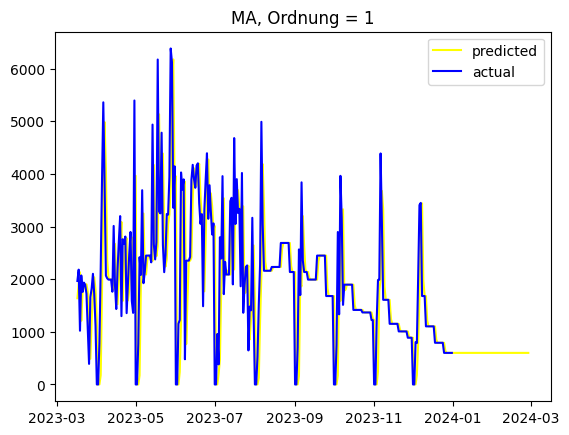

mean absolute error (mae): ARIMA: 2031.2703, simple: 622.0345
mean squared error (mse): ARIMA: 5538149.9819, simple: 1171352.5655
mean absolute percentage error (mape): ARIMA: 0.3065, simple: 0.3035
Log Likelihood: -2675.3806, AIC: 5356.7612


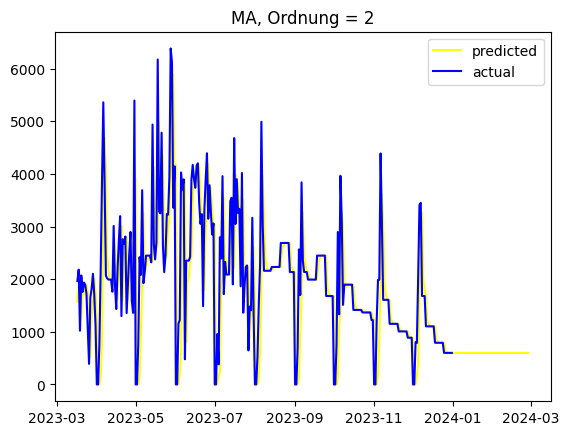

mean absolute error (mae): ARIMA: 2031.2803, simple: 622.0345
mean squared error (mse): ARIMA: 5538258.4102, simple: 1171352.5655
mean absolute percentage error (mape): ARIMA: 0.3143, simple: 0.3035
Log Likelihood: -2666.3868, AIC: 5340.7735


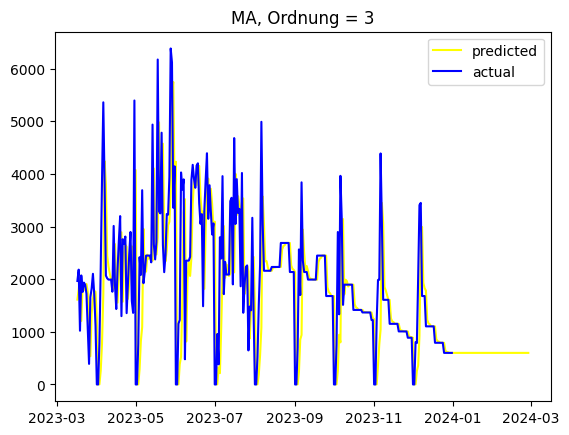

mean absolute error (mae): ARIMA: 2031.2844, simple: 622.0345
mean squared error (mse): ARIMA: 5538361.3588, simple: 1171352.5655
mean absolute percentage error (mape): ARIMA: 0.3108, simple: 0.3035
Log Likelihood: -2662.3179, AIC: 5334.6357


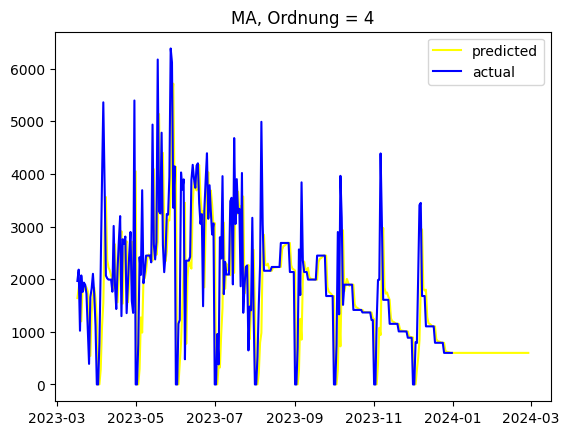

mean absolute error (mae): ARIMA: 2031.2861, simple: 622.0345
mean squared error (mse): ARIMA: 5538404.9943, simple: 1171352.5655
mean absolute percentage error (mape): ARIMA: 0.3084, simple: 0.3035
Log Likelihood: -2657.6507, AIC: 5327.3014


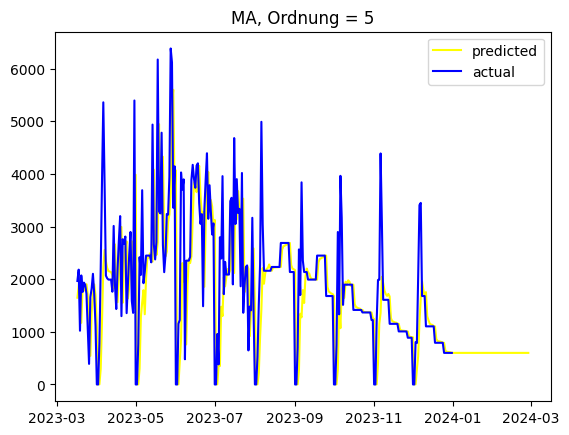

mean absolute error (mae): ARIMA: 2031.2865, simple: 622.0345
mean squared error (mse): ARIMA: 5538363.8912, simple: 1171352.5655
mean absolute percentage error (mape): ARIMA: 0.2868, simple: 0.3035
Log Likelihood: -2652.1579, AIC: 5318.3157


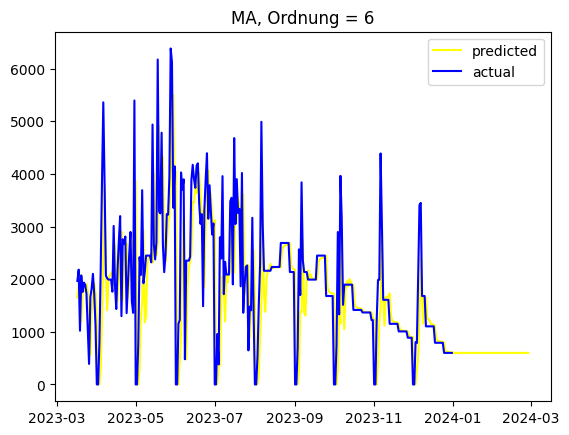

mean absolute error (mae): ARIMA: 2031.2880, simple: 622.0345
mean squared error (mse): ARIMA: 5538326.5205, simple: 1171352.5655
mean absolute percentage error (mape): ARIMA: 0.2859, simple: 0.3035


In [19]:
ma_arima()

Log Likelihood: -2635.7658, AIC: 5277.5315


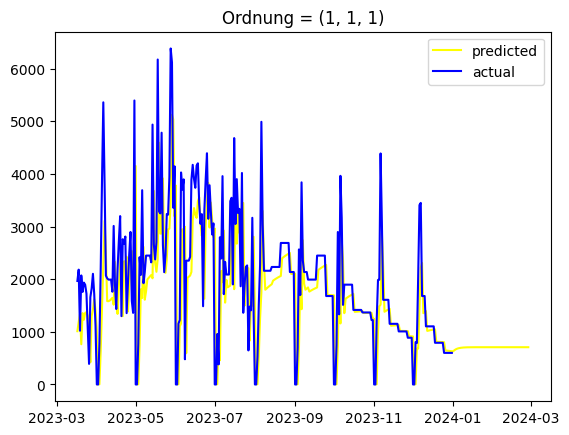

mean absolute error (mae): ARIMA: 2031.2800, simple: 622.0345
mean squared error (mse): ARIMA: 5538430.9509, simple: 1171352.5655
mean absolute percentage error (mape): ARIMA: 0.2987, simple: 0.3035
Log Likelihood: -2620.4123, AIC: 5248.8245


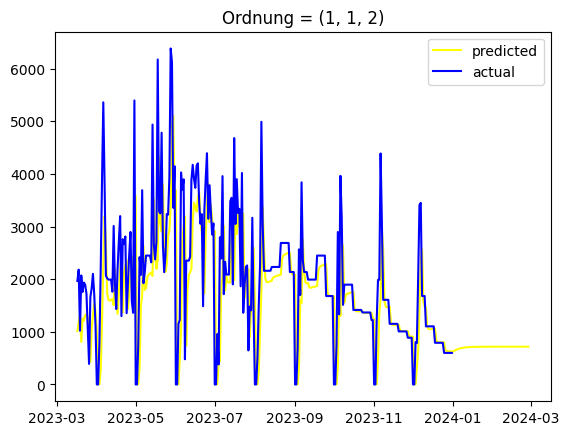

mean absolute error (mae): ARIMA: 2031.3201, simple: 622.0345
mean squared error (mse): ARIMA: 5538495.7491, simple: 1171352.5655
mean absolute percentage error (mape): ARIMA: 0.2969, simple: 0.3035
Log Likelihood: -2620.3769, AIC: 5250.7537


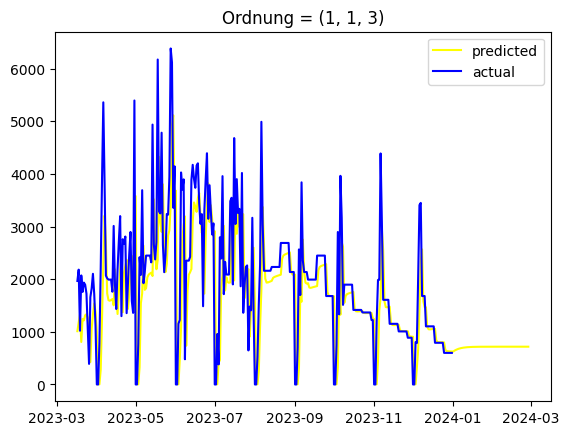

mean absolute error (mae): ARIMA: 2031.3202, simple: 622.0345
mean squared error (mse): ARIMA: 5538490.4931, simple: 1171352.5655
mean absolute percentage error (mape): ARIMA: 0.2967, simple: 0.3035
Log Likelihood: -2620.3763, AIC: 5252.7527


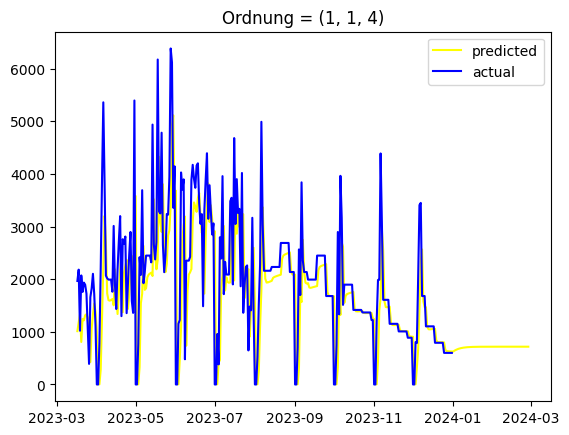

mean absolute error (mae): ARIMA: 2031.3202, simple: 622.0345
mean squared error (mse): ARIMA: 5538491.0818, simple: 1171352.5655
mean absolute percentage error (mape): ARIMA: 0.2967, simple: 0.3035
Log Likelihood: -2619.9671, AIC: 5253.9343


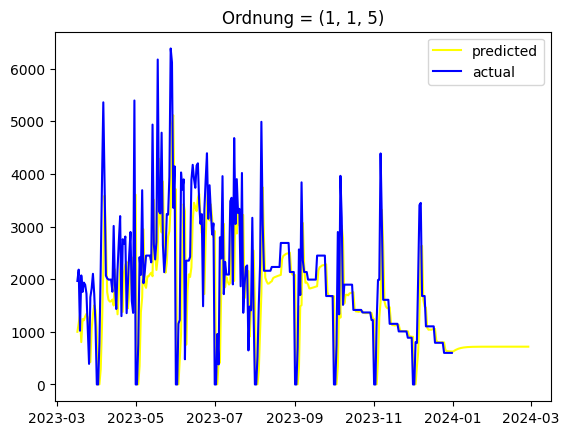

mean absolute error (mae): ARIMA: 2031.3203, simple: 622.0345
mean squared error (mse): ARIMA: 5538489.9643, simple: 1171352.5655
mean absolute percentage error (mape): ARIMA: 0.3004, simple: 0.3035
Log Likelihood: -2619.9592, AIC: 5255.9184


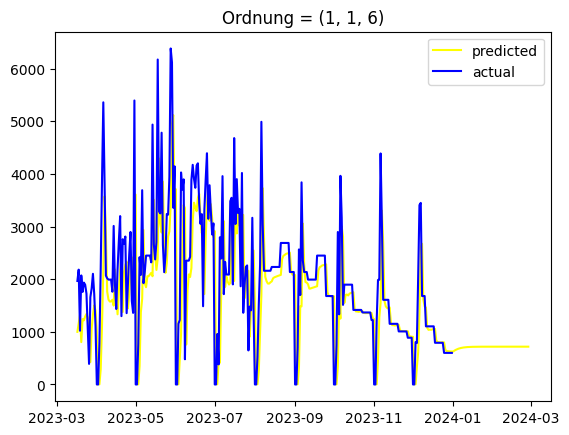

mean absolute error (mae): ARIMA: 2031.3203, simple: 622.0345
mean squared error (mse): ARIMA: 5538492.5693, simple: 1171352.5655
mean absolute percentage error (mape): ARIMA: 0.3015, simple: 0.3035
Log Likelihood: -2619.7169, AIC: 5257.4337


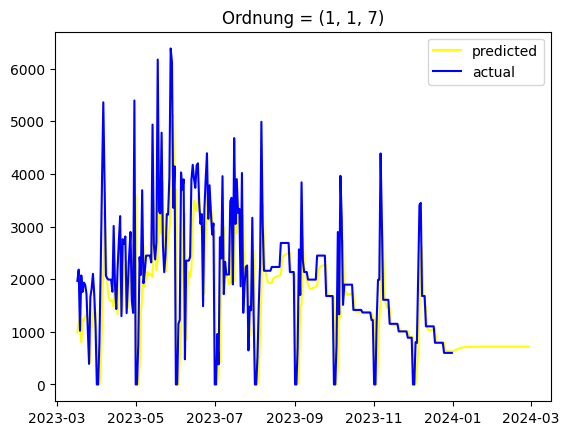

mean absolute error (mae): ARIMA: 2031.3211, simple: 622.0345
mean squared error (mse): ARIMA: 5538498.6081, simple: 1171352.5655
mean absolute percentage error (mape): ARIMA: 0.2969, simple: 0.3035


In [21]:
for i in range(1, 8):
    p, d, q = 1, 1, i

    arima = SARIMAX(df_train['log'], order=(p, d, q))
    result = arima.fit()
    #print(result.summary())
    print('Log Likelihood: {:.4f}, AIC: {:.4f}'.format(result.llf, result.aic))
    # Update des DataFrames
    df['differences'] = df_train['differences']
    model = SARIMAX(df['log'], order=(p, d, q))
    result_new = model.filter(result.params)

    # Vorhersage
    predicted = result_new.predict(start=start_date, end=future_date)
    tmp = pd.DataFrame(predicted)
    tmp['crossings'] = tmp['predicted_mean']
    tmp.index = tmp.index.date
    tmp['crossings'] =  np.exp(tmp['crossings'])
    tmp['crossings'] = scaler.inverse_transform(tmp[['crossings']])

    # Mergen der Daten
    df_r = pd.concat([df_train, tmp], axis=1)
    #df_r = df_train.merge(tmp, how='left', left_index=True, right_index=True)

    df_r[header] = df_r[header].fillna(df_r['crossings'])
    df_r = pd.DataFrame(df_r)
    df_r.index = pd.to_datetime(df_r.index)

    # Plotten
    plt.title('Ordnung = (1, 1, {:.0f})'.format(i))
    plt.plot(df_r.loc[start_date:future_date, header],
         color='yellow', label='predicted')
    plt.plot(df.loc[start_date:end_date, header], color='blue', label='actual')
    plt.legend()
    plt.show()

    y_pred_simple = df_test[header].iloc[:-1]
    y_pred_simple = pd.concat([y_pred_simple, df_train[header].iloc[-1:]])
    y_pred_simple = y_pred_simple.sort_index().tolist()

    df_test.loc[:,'intervals'] = (df_test[header] > 10).astype(int).diff().fillna(0).ne(0).cumsum()
    df_test.loc[:,'group'] = df_test[header].apply(lambda x: '≤ 10' if x <= 10 else '> 10')
    df_test.loc[:,'predicted'] = df_r.loc[start_date:end_date, header]
    df_test.loc[:,'simple_predict'] = y_pred_simple

    greater = df_test[df_test['group'] == '> 10']
    mape_arima = []
    mape_simple = []

    for name, group in greater.groupby('intervals'):
        mape_arima.append(mean_absolute_percentage_error(group[header], group['predicted']))
        mape_simple.append(mean_absolute_percentage_error(group[header], group['simple_predict']))

    mae_arima = np.mean(np.abs(df_test[header] - predicted))
    mse_arima = np.mean(np.square(df_test[header] - predicted))
    mape_arima = sum(mape_arima)/len(mape_arima)
    mae_simple = np.mean(np.abs(df_test[header] - y_pred_simple))
    mse_simple = np.mean(np.square(df_test[header] - y_pred_simple))
    mape_simple = sum(mape_simple)/len(mape_simple)

    print("mean absolute error (mae): ARIMA: {:.4f}, simple: {:.4f}".format(mae_arima, mae_simple))
    print("mean squared error (mse): ARIMA: {:.4f}, simple: {:.4f}".format(mse_arima, mse_simple))
    print("mean absolute percentage error (mape): ARIMA: {:.4f}, simple: {:.4f}".format(mape_arima, mape_simple))